<a href="https://colab.research.google.com/github/audrey282/BSD/blob/main/BSD(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bike Sharing Demand
Importing necessary libraries (pandas, seaborn, matplotlib.pyplot) for data manipulation and visualization. It then loads the train.csv dataset into a pandas DataFrame named df, converts the 'datetime' column to datetime objects, and extracts the 'hour' from the 'datetime' column, adding it as a new column to the DataFrame.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# loading and preaparing data
df = pd.read_csv('train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

## Member 1: Data Preparation and Initial Exploration

A data quality check by printing the sum of null values for each column in the DataFrame. This helps in identifying missing data.

Execution Status: Not yet executed
Standard Output:

In [ ]:
# data quality check
print("Checking for missing values:")
print(df.isnull().sum())

Checking for missing values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
hour          0
dtype: int64


In [ ]:
season_summary = df.groupby('season')['count'].sum().reset_index()

# Rename for clarity
season_summary.columns = ['Season', 'Total Rentals']

season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
season_summary['Season'] = season_summary['Season'].map(season_map)

print(season_summary)

   Season  Total Rentals
0  Spring         312498
1  Summer         588282
2    Fall         640662
3  Winter         544034


In [ ]:
season_summary.to_csv('season_summary.csv', index=False)

A box plot to show the distribution of bike rental demand ('count') across different seasons. It uses `seaborn.boxplot` and labels the x-axis with season names.

/tmp/ipykernel_1283/2776406919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='count', palette='Set2')


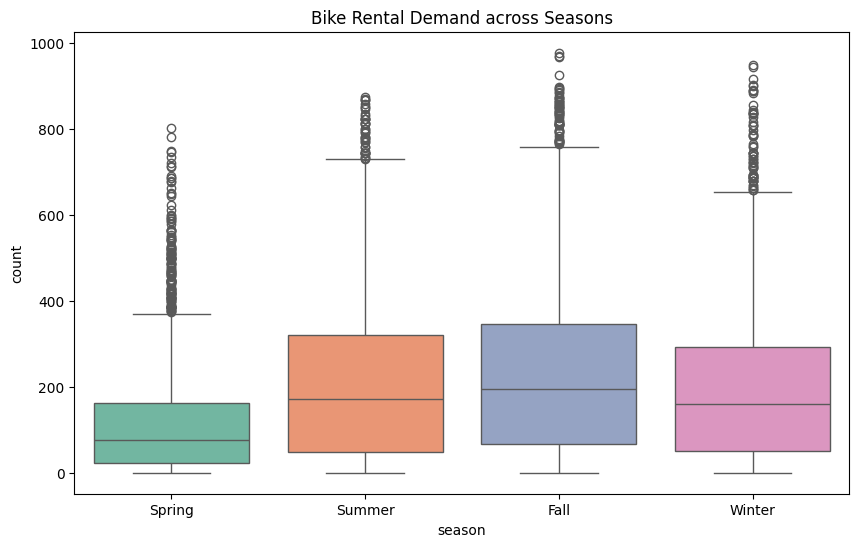

In [ ]:
# Seasonal Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='season', y='count', palette='Set2')
plt.title('Bike Rental Demand across Seasons')

plt.xticks(ticks=[0, 1, 2, 3], labels=['Spring', 'Summer', 'Fall', 'Winter'])

plt.show()

In [ ]:
weather_summary = df.groupby('weather')['count'].sum().reset_index()

weather_summary.columns = ['Weather', 'Total Rentals']

weather_map = {
    1:'Clear',
    2:'Mist',
    3:'Light Rain/Snow',
    4:'Heavy Rain/Storm'
}
weather_summary['Weather'] = weather_summary['Weather'].map(weather_map)

print(weather_summary)

            Weather  Total Rentals
0             Clear        1476063
1              Mist         507160
2   Light Rain/Snow         102089
3  Heavy Rain/Storm            164


In [ ]:
weather_summary.to_csv('weather_summary.csv', index=False)

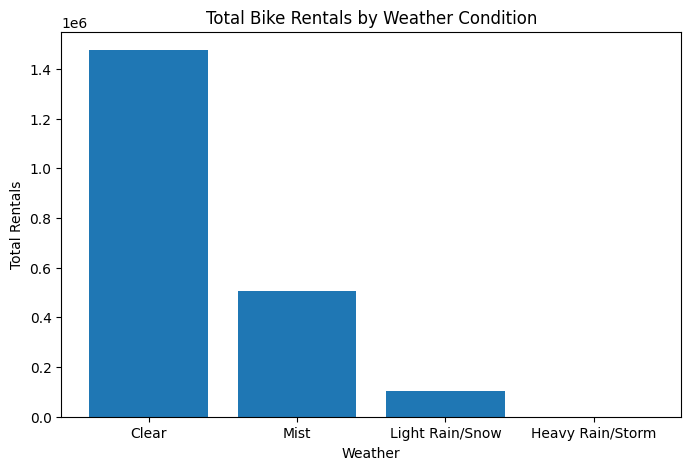

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(weather_summary['Weather'], weather_summary['Total Rentals'])
plt.title('Total Bike Rentals by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Total Rentals')
plt.show()

A correlation heatmap to visualize the relationships between numerical features, specifically focusing on weather-related variables and demand. It first selects only numeric columns from the DataFrame to avoid errors and then uses `seaborn.heatmap` to plot the correlation matrix.

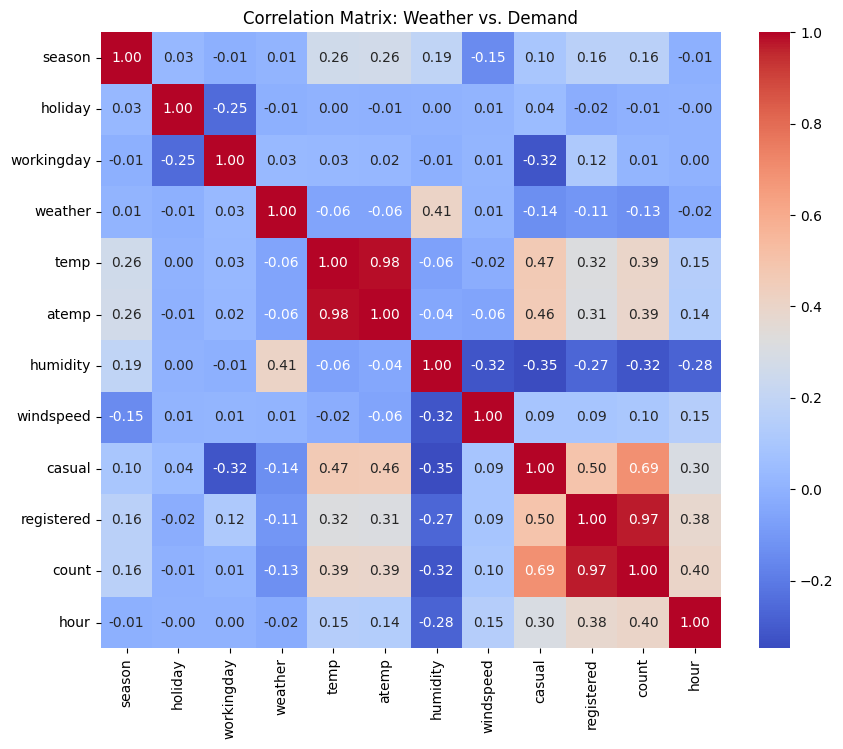

In [ ]:
# Correlation heatmap
#only contributes numeric values in order to avoid errors
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Weather vs. Demand')
plt.show()

A point plot to visualize the average bike rental demand ('count') per hour, distinguishing between working days and weekends/holidays. This helps in understanding hourly demand patterns based on the type of day

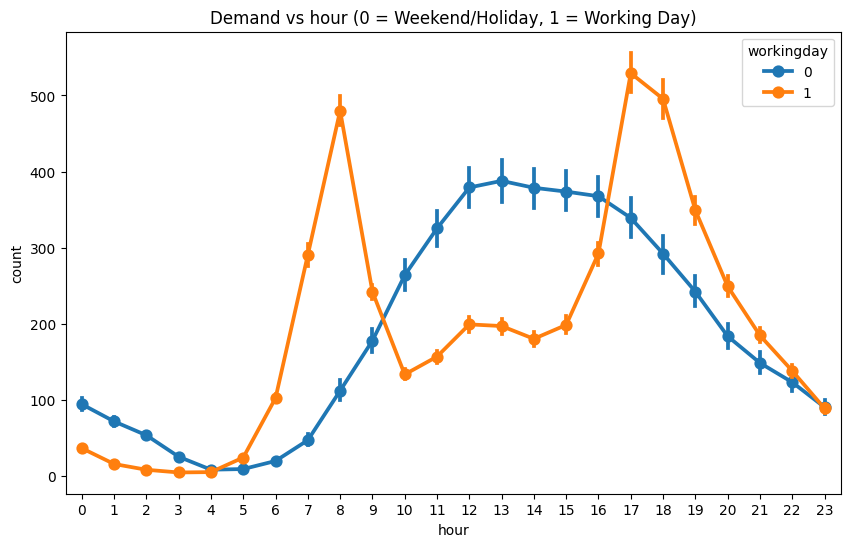

In [ ]:
# Hourly Demand (Weekday vs Weekend)
plt.figure(figsize=(10,6))
sns.pointplot(data=df, x='hour', y='count', hue='workingday')
plt.title('Demand vs hour (0 = Weekend/Holiday, 1 = Working Day)')
plt.show()

In [ ]:
workingday_summary = df.groupby('workingday')['count'].sum().reset_index()

workingday_summary.columns = ['Working Day', 'Total Rentals']

# Map values for clarity
workingday_map = {0: 'Non-Working Day (Weekend/Holiday)', 1: 'Working Day'}
workingday_summary['Working Day'] = workingday_summary['Working Day'].map(workingday_map)

print(workingday_summary)

                         Working Day  Total Rentals
0  Non-Working Day (Weekend/Holiday)         654872
1                        Working Day        1430604


In [ ]:
workingday_summary.to_csv('workingday_summary.csv', index=False)

A heatmap to visualize the average bike rental demand across different hours of the day and days of the week. It first extracts the 'day_of_week' from the datetime column, creates a pivot table with average counts, and then uses `seaborn.heatmap` to display the results.

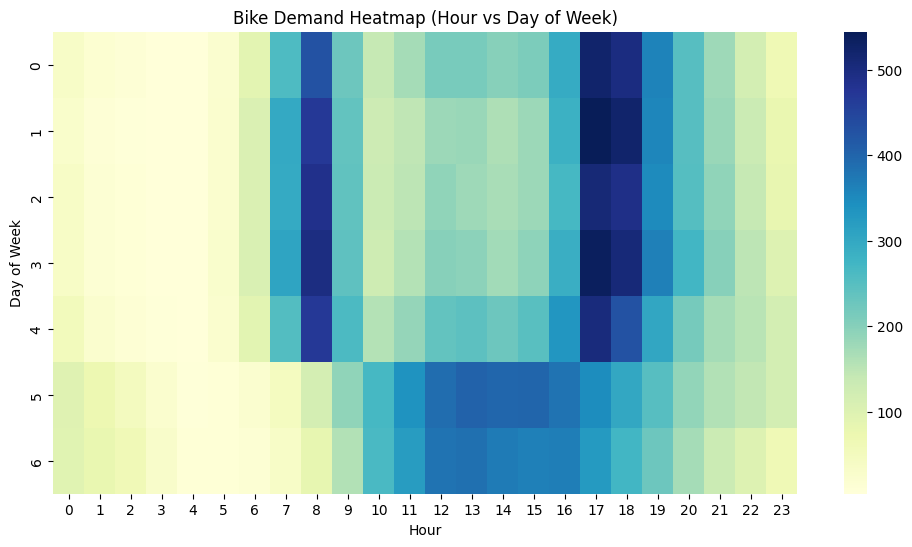

In [ ]:
# Demand Heatmap (Hour vs Day)
df['day_of_week'] = df['datetime'].dt.dayofweek

pivot = df.pivot_table(values='count',
                       index='day_of_week',
                       columns='hour',
                       aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")

plt.title("Bike Demand Heatmap (Hour vs Day of Week)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")

plt.show()

A histogram to visualize the distribution of the target variable, 'count' (bike rental demand). This helps in understanding the skewness and general shape of the demand distribution.

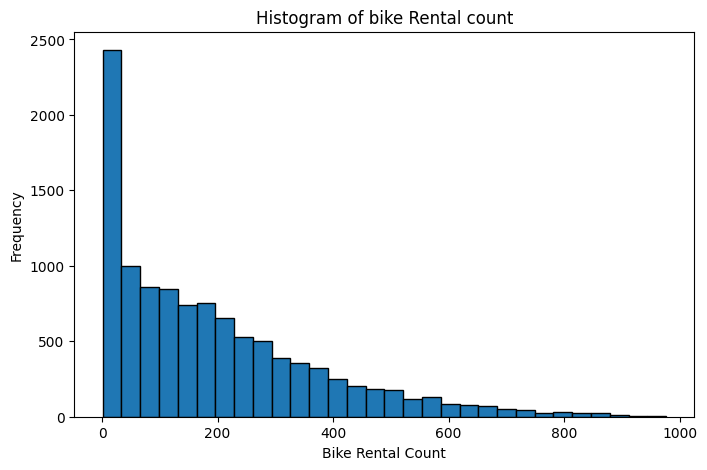

In [ ]:
# Check skewness of target variable. (Demand distribution)
plt.figure(figsize=(8,5))
plt.hist(df['count'], bins=30, edgecolor='black')
plt.title('Histogram of bike Rental count')
plt.xlabel('Bike Rental Count')
plt.ylabel('Frequency')
plt.show()

Reloading the `train.csv` dataset and performs further feature extraction. It converts the 'datetime' column to datetime objects and then extracts 'hour', 'day', 'month', and 'year' as new numerical features.

In [ ]:
# Feature Extraction
# data loaded
df = pd.read_csv ('train.csv')

# data converted into real datetime format
df ['datetime']= pd.to_datetime (df ['datetime'])

# the features that needs to be extracted can add more colums accordingly
df ['hour'] = df ['datetime'].dt.hour
df ['day'] = df ['datetime'].dt.day
df ['month']= df ['datetime'].dt.month
df ['year'] = df ['datetime'].dt.year

Extracting the 'day of week' as a numerical value (0 for Monday, 6 for Sunday) from the 'datetime' column and adds it as a new column to the DataFrame.

In [ ]:
# for extracting day of week as number e.g. (0=Monday,6=Sunday)
df ['day_of_week']= df ['datetime'].dt.dayofweek

A new binary feature named 'is weekend' which is 1 if the 'day_of_week' is Saturday (5) or Sunday (6), and 0 otherwise.

In [ ]:
# identifying if it's a weekend (5=Saturday,6=Sunday)
df['is_weekend']=df ['day_of_week'].apply (lambda x:1 if x>=5 else 0)

Creating a 'is_rush_hour' binary feature. It initializes the column with zeros and then sets it to 1 if it's a working day and the hour falls within typical rush hour periods (7-9 AM and 4-7 PM).

In [ ]:
# rush hour column, yes for 1 and no for 0
df ['is_rush_hour']=0
df.loc[(df['workingday']==1) & (df['hour'].isin([7,8,9,16,17,18,19])), 'is_rush_hour']=1

The first few rows of the DataFrame using `df.head()`. This is used to verify that the newly created columns and transformations are correctly applied.

In [ ]:
# showing the few rows in order to know that the cols. are created
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,month,year,day_of_week,is_weekend,is_rush_hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1,1,2011,5,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1,2011,5,1,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1,1,2011,5,1,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,1,1,2011,5,1,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,1,1,2011,5,1,0


The total number of rows and columns in the DataFrame `df` using df.shape. This provides an overview of the dataset's dimensions.

In [ ]:
# For checking the total number or rows and cols.
print ("Total Rows :" , df.shape[0])
print ("Total Colums:", df.shape[1])

Total Rows : 10886
Total Colums: 19


The names of all columns currently present in the DataFrame `df`. This is useful for reviewing the available features after data preprocessing.

In [ ]:
# for showing the namesof all  the col
print ("\nYour current colums are:")
print (df.columns)


Your current colums are:
Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'hour', 'day', 'month', 'year', 'day_of_week', 'is_weekend',
       'is_rush_hour'],
      dtype='object')


One-hot encoding on the 'season' and 'weather' categorical columns using `pd.get_dummies`. This converts categorical variables into a numerical format suitable for machine learning models and then displays the head of the DataFrame to show the new columns.

In [ ]:
# one hot encoding
df = pd.get_dummies (df,columns=['season','weather'],prefix =('season','weather'))
df.head()

,datetime,holiday,workingday,temp,atemp,humidity,windspeed,casual,registered,count,...,is_weekend,is_rush_hour,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,2011-01-01 00:00:00,0,0,9.84,14.395,81,0.0,3,13,16,...,1,0,True,False,False,False,True,False,False,False
1,2011-01-01 01:00:00,0,0,9.02,13.635,80,0.0,8,32,40,...,1,0,True,False,False,False,True,False,False,False
2,2011-01-01 02:00:00,0,0,9.02,13.635,80,0.0,5,27,32,...,1,0,True,False,False,False,True,False,False,False
3,2011-01-01 03:00:00,0,0,9.84,14.395,75,0.0,3,10,13,...,1,0,True,False,False,False,True,False,False,False
4,2011-01-01 04:00:00,0,0,9.84,14.395,75,0.0,0,1,1,...,1,0,True,False,False,False,True,False,False,False


 The features `(x)` and the target variable `(y)` for the machine learning model. It drops the 'count', 'datetime', 'casual', and 'registered' columns from the DataFrame to form the feature set `x`, and assigns the 'count' column as the target variable `y`.

In [ ]:
# feature defining for modeling
from sklearn.model_selection import train_test_split

x = df.drop(['count','datetime','casual','registered'],axis=1 )
y = df['count']

Spliting the dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. It allocates 80% of the data for training (`x_train`, `y_train`) and 20% for testing (`x_test`, `y_test`), ensuring reproducibility with `random_state=42`. It then prints the number of rows in the training and testing sets.

In [ ]:
# Train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print('Data is split and ready!')
print('Training rows :',x_train.shape[0])
print ('Testing rows :',x_test.shape[0])

Data is split and ready!
Training rows : 8708
Testing rows : 2178


Reloads and preprocesses the DataFrame `df` to ensure all previous feature engineering steps are applied consistently. It then defines `x` and `y` and performs the train-test split again. Subsequently, it initializes `StandardScaler` and scales the numerical features ('temp', 'atemp', 'humidity', 'windspeed') in both `x_train` and `x_test` to standardize their ranges. Finally, it prints the head of the scaled `x_train` and `x_test` to show the result of scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Re-load and preprocess df to ensure it's available and correctly prepared
df = pd.read_csv('train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_rush_hour'] = 0
df.loc[(df['workingday'] == 1) & (df['hour'].isin([7, 8, 9, 16, 17, 18, 19])), 'is_rush_hour'] = 1
df = pd.get_dummies(df, columns=['season', 'weather'], prefix=('season', 'weather'))

# Define x and y, and perform train-test split
x = df.drop(['count', 'datetime', 'casual', 'registered'], axis=1)
y = df['count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

num_cols = ['temp', 'atemp', 'humidity', 'windspeed']

# Apply scaling to x_train and x_test
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

print("Numerical features in x_train and x_test scaled successfully.")
print("x_train head after scaling:")
print(x_train.head())
print("\nx_test head after scaling:")
print(x_test.head())

Numerical features in x_train and x_test scaled successfully.
x_train head after scaling:
      holiday  workingday      temp     atemp  humidity  windspeed  hour  day  \
2815        0           1  0.977262  0.960505  1.098553  -0.828356     5    6   
8695        0           0  2.135457  2.034991 -1.182694   0.878555    16    4   
8406        0           1  1.609005  1.407912 -1.079001   0.512496    15   11   
1543        0           0 -0.707385 -0.651814  1.617019  -0.706609     4   10   
4952        0           0 -0.917966 -1.009976 -0.871615   0.512496    10   19   

      month  year  ...  is_weekend  is_rush_hour  season_1  season_2  \
2815      7  2011  ...           0             0     False     False   
8695      8  2012  ...           1             0     False     False   
8406      7  2012  ...           0             0     False     False   
1543      4  2011  ...           1             0     False      True   
4952     11  2011  ...           1             0     False     

Initializes and trains a Linear Regression model (`model_lr`) using the scaled training data (`x_train`, `y_train`). After fitting the model, it generates predictions (`pred_lr`) on the test data (`x_test`).

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(x_train, y_train)

pred_lr = model_lr.predict(x_test)
print("Linear Regression model re-trained and predictions generated.")

Linear Regression model re-trained and predictions generated.


Evaluates the performance of the Linear and Ridge Regression model. It calculates and prints three common regression metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) using the actual test values (`y_test`) and the model's predictions (`pred_lr`).

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Performance")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression Performance
RMSE: 109.40654155748436
MAE: 83.4793400196883
R2: 0.6373552702827874


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # you can tune alpha later if needed
ridge.fit(x_train, y_train)
print("Ridge model trained successfully")

Ridge model trained successfully


In [ ]:
pred_ridge = ridge.predict(x_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
mae_ridge = mean_absolute_error(y_test, pred_ridge)
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge Regression Performance")
print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)
print("R2:", r2_ridge)

Ridge Regression Performance
RMSE: 109.40614648369332
MAE: 83.46975188608452
R2: 0.6373578893431735


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'RMSE': [rmse_lr, rmse_ridge],
    'MAE': [mae_lr, mae_ridge],
    'R2 Score': [r2_lr, r2_ridge]
})

comparison_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,109.406542,83.479340,0.637355
1,Ridge Regression,109.406146,83.469752,0.637358


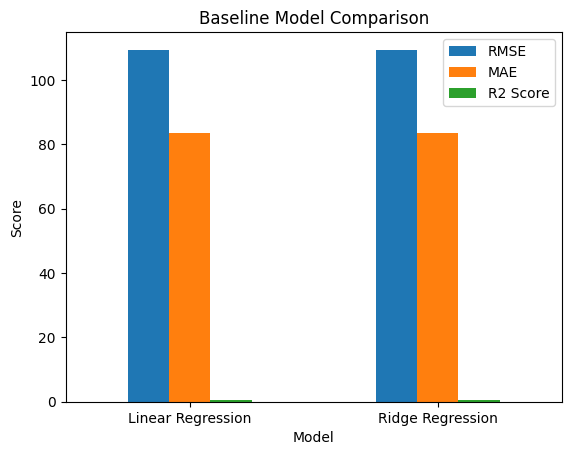

In [ ]:
comparison_df.set_index('Model')[['RMSE','MAE','R2 Score']].plot(kind='bar')
plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

## END-TO-END: Random Forest Regression | Hyperparameter Optimization + Explainability

### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train Random Forest Regressor
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(x_train, y_train)

# Make predictions
pred_rf = model_rf.predict(x_test)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Regressor Performance")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest Regressor Performance
RMSE: 39.1907165011236
MAE: 24.55981634527089
R2: 0.9534669844498229


This cell initializes and trains a `RandomForestRegressor` model with default parameters. It then makes predictions on the test set and evaluates its performance using RMSE, MAE, and R2 score.

### Hyperparameter Optimization for Random Forest using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],  # Number of trees in the forest
    'max_depth': [10, 20],      # Maximum depth of the tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]   # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2,
                           scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best RMSE found: ", np.sqrt(-grid_search.best_score_))

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
pred_best_rf = best_rf_model.predict(x_test)

# Evaluate the best model
rmse_best_rf = np.sqrt(mean_squared_error(y_test, pred_best_rf))
mae_best_rf = mean_absolute_error(y_test, pred_best_rf)
r2_best_rf = r2_score(y_test, pred_best_rf)

print("\nOptimized Random Forest Regressor Performance")
print("RMSE:", rmse_best_rf)
print("MAE:", mae_best_rf)
print("R2:", r2_best_rf)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters found:  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE found:  44.19768142039372

Optimized Random Forest Regressor Performance
RMSE: 39.07881934544932
MAE: 24.492850380557176
R2: 0.9537323268152273


This cell performs hyperparameter optimization for the `RandomForestRegressor` using `GridSearchCV`. It defines a parameter grid and searches for the best combination of `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` that minimizes the negative mean squared error. It then trains the best model and evaluates its performance.

### Model Explainability: Feature Importance

This cell extracts feature importances from the best-optimized Random Forest model. It then creates a DataFrame to store and sort these importances and visualizes them using a bar plot to show which features contributed most to the model's predictions.

### Updated Model Comparison

                     Model        RMSE        MAE  R2 Score
0        Linear Regression  109.406542  83.479340  0.637355
1         Ridge Regression  109.406146  83.469752  0.637358
2            Random Forest   39.190717  24.559816  0.953467
3  Optimized Random Forest   39.078819  24.492850  0.953732


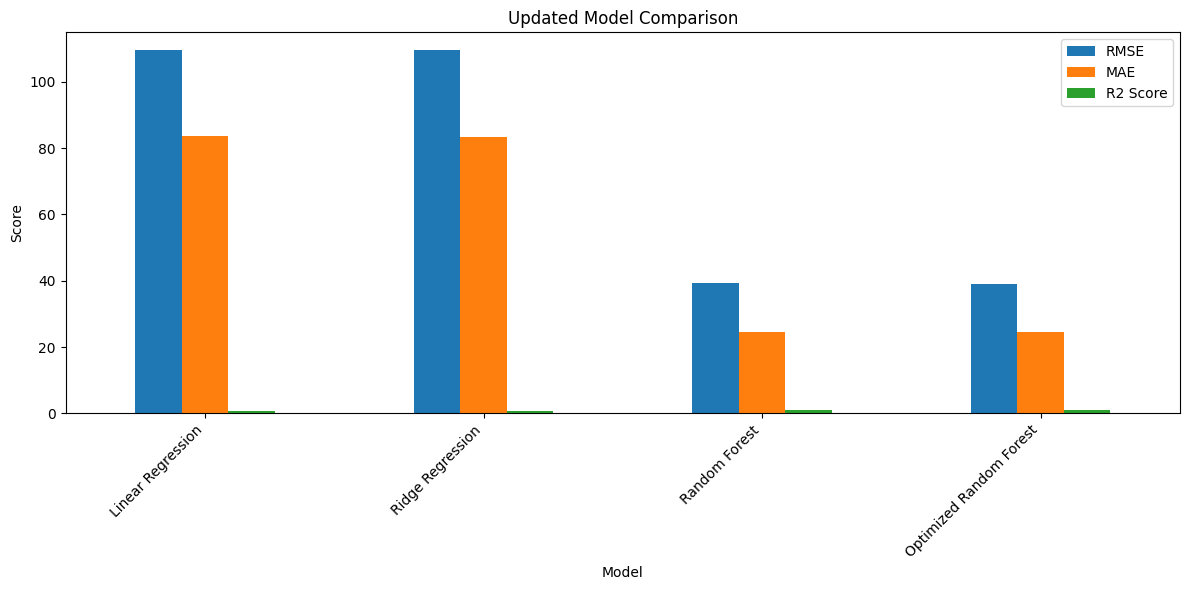

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Add Random Forest and Optimized Random Forest results to the comparison DataFrame
comparison_df_updated = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Optimized Random Forest'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_rf, rmse_best_rf],
    'MAE': [mae_lr, mae_ridge, mae_rf, mae_best_rf],
    'R2 Score': [r2_lr, r2_ridge, r2_rf, r2_best_rf]
})

print(comparison_df_updated)

comparison_df_updated.set_index('Model')[['RMSE','MAE','R2 Score']].plot(kind='bar', figsize=(12, 6))
plt.title('Updated Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This cell updates the model comparison DataFrame to include the performance metrics of the standard Random Forest and the optimized Random Forest models. It then prints the updated DataFrame and visualizes the comparison of RMSE, MAE, and R2 scores across all models using a bar plot.

### XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

# Initialize and train XGBoost Regressor
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(x_train, y_train)

# Make predictions
pred_xgb = model_xgb.predict(x_test)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb = mean_absolute_error(y_test, pred_xgb)
r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost Regressor Performance")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Performance
RMSE: 37.18707162305789
MAE: 24.12141990661621
R2: 0.9581034183502197


This cell initializes and trains an `XGBRegressor` model with default parameters. It then makes predictions on the test set and evaluates its performance using RMSE, MAE, and R2 score.

### Updated Model Comparison with XGBoost

                     Model        RMSE        MAE  R2 Score
0        Linear Regression  109.406542  83.479340  0.637355
1         Ridge Regression  109.406146  83.469752  0.637358
2            Random Forest   39.190717  24.559816  0.953467
3  Optimized Random Forest   39.078819  24.492850  0.953732
4                  XGBoost   37.187072  24.121420  0.958103


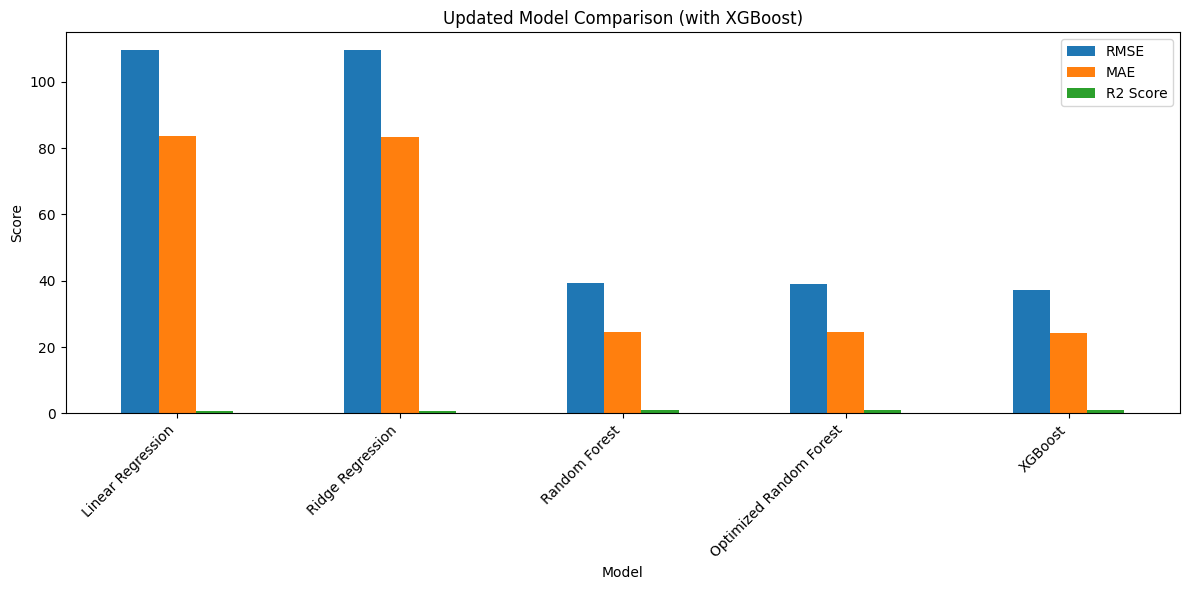

In [ ]:
# Add XGBoost results to the comparison DataFrame
comparison_df_updated_xgb = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Optimized Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_rf, rmse_best_rf, rmse_xgb],
    'MAE': [mae_lr, mae_ridge, mae_rf, mae_best_rf, mae_xgb],
    'R2 Score': [r2_lr, r2_ridge, r2_rf, r2_best_rf, r2_xgb]
})

print(comparison_df_updated_xgb)

comparison_df_updated_xgb.set_index('Model')[['RMSE','MAE','R2 Score']].plot(kind='bar', figsize=(12, 6))
plt.title('Updated Model Comparison (with XGBoost)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Member 4: Model Explainability and Deployment

### Observations on Updated Model Comparison (with XGBoost)

This final comparison clearly demonstrates the superior performance of tree-based models, especially after optimization:

*   **XGBoost as Best Performer**: XGBoost achieved the lowest RMSE (37.19) and MAE (24.12) and the highest R2 score (0.958) among all models, indicating it is the most accurate predictive model for this dataset.
*   **Significant Improvement over Baselines**: Both Random Forest and XGBoost models drastically outperform Linear and Ridge Regression, which had much higher RMSE/MAE and significantly lower R2 scores (around 0.637).
*   **Value of Hyperparameter Optimization**: The optimized Random Forest model showed a slight but noticeable improvement over the default Random Forest, highlighting the benefits of tuning hyperparameters.
*   **Overall Model Choice**: Based on these metrics, the XGBoost Regressor is the recommended model for predicting bike rental demand in this project due to its excellent predictive power.

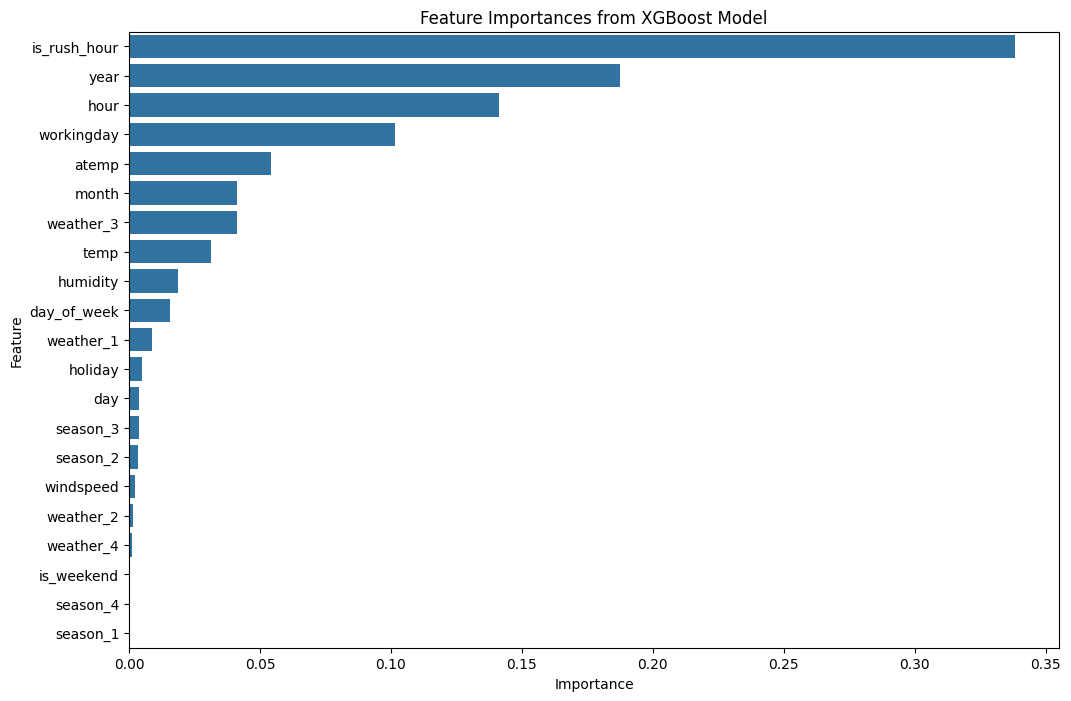

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances from the XGBoost model
feature_importances = model_xgb.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': x_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importances from XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

This cell updates the model comparison DataFrame to include the performance metrics of the XGBoost model. It then prints the updated DataFrame and visualizes the comparison of RMSE, MAE, and R2 scores across all models using a bar plot.

### Further Model Explainability Techniques

#### Actual vs Predicted Plot

This plot visually compares the actual bike rental counts with the values predicted by our optimized Random Forest model. A good model will have predictions that cluster closely around the diagonal line, indicating high accuracy.

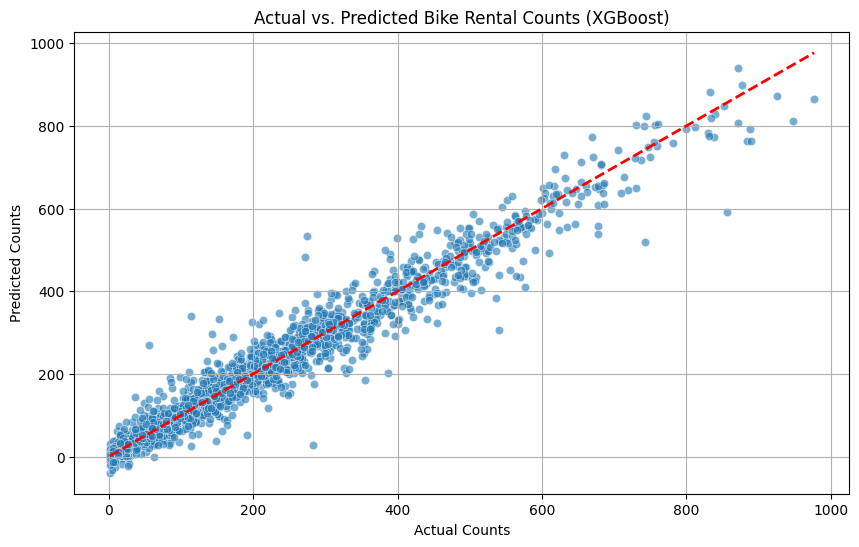

Actual vs Predicted plot generated for XGBoost.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.title('Actual vs. Predicted Bike Rental Counts (XGBoost)')
plt.xlabel('Actual Counts')
plt.ylabel('Predicted Counts')
plt.grid(True)
plt.show()

print("Actual vs Predicted plot generated for XGBoost.")

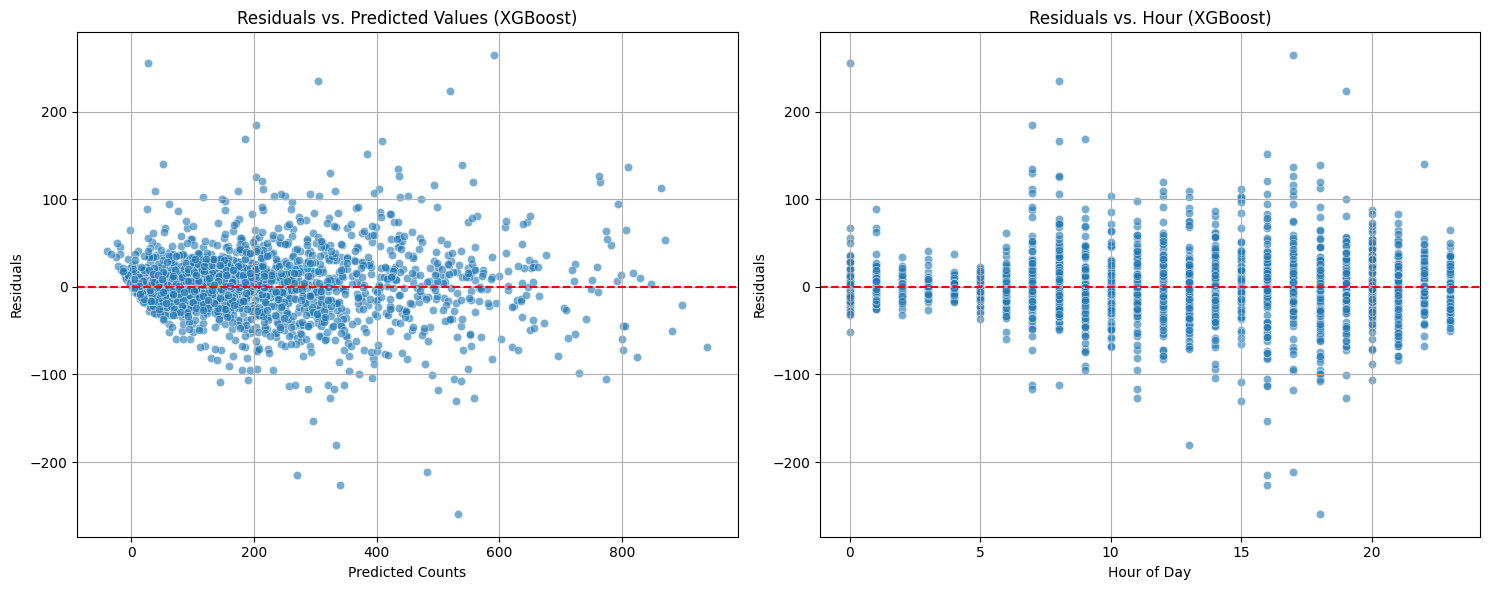

Residual plots generated for XGBoost model.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# --- Ensure all necessary variables are defined for robustness ---
# This section re-runs critical steps in case previous cells were not executed
# or the kernel state was reset.

# Re-load and preprocess df if not already done in the current session
if 'df' not in locals():
    df = pd.read_csv('train.csv')
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    df['is_rush_hour'] = 0
    df.loc[(df['workingday'] == 1) & (df['hour'].isin([7, 8, 9, 16, 17, 18, 19])), 'is_rush_hour'] = 1
    df = pd.get_dummies(df, columns=['season', 'weather'], prefix=('season', 'weather'))

# Define x and y, and perform train-test split
x = df.drop(['count', 'datetime', 'casual', 'registered'], axis=1)
y = df['count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['temp', 'atemp', 'humidity', 'windspeed']
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

# Initialize and train XGBoost Regressor and make predictions
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(x_train, y_train)
pred_xgb = model_xgb.predict(x_test)

# --- End of robustness section ---

# Calculate residuals for the XGBoost model
residuals_xgb = y_test - pred_xgb

plt.figure(figsize=(15, 6))

# Plot 1: Residuals vs. Predicted Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=pred_xgb, y=residuals_xgb, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (XGBoost)')
plt.xlabel('Predicted Counts')
plt.ylabel('Residuals')
plt.grid(True)

# Plot 2: Residuals vs. Hour
# Assuming 'hour' is available in x_test, which is ensured by the robustness section
plt.subplot(1, 2, 2)
sns.scatterplot(x=x_test['hour'], y=residuals_xgb, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Hour (XGBoost)')
plt.xlabel('Hour of Day')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Residual plots generated for XGBoost model.")

#### Surrogate Tree (trained on RF predictions)

A surrogate model is a simpler, interpretable model (like a Decision Tree) trained to mimic the predictions of a more complex model (like our Random Forest). By analyzing the surrogate model, we can gain insights into the complex model's decision-making process.

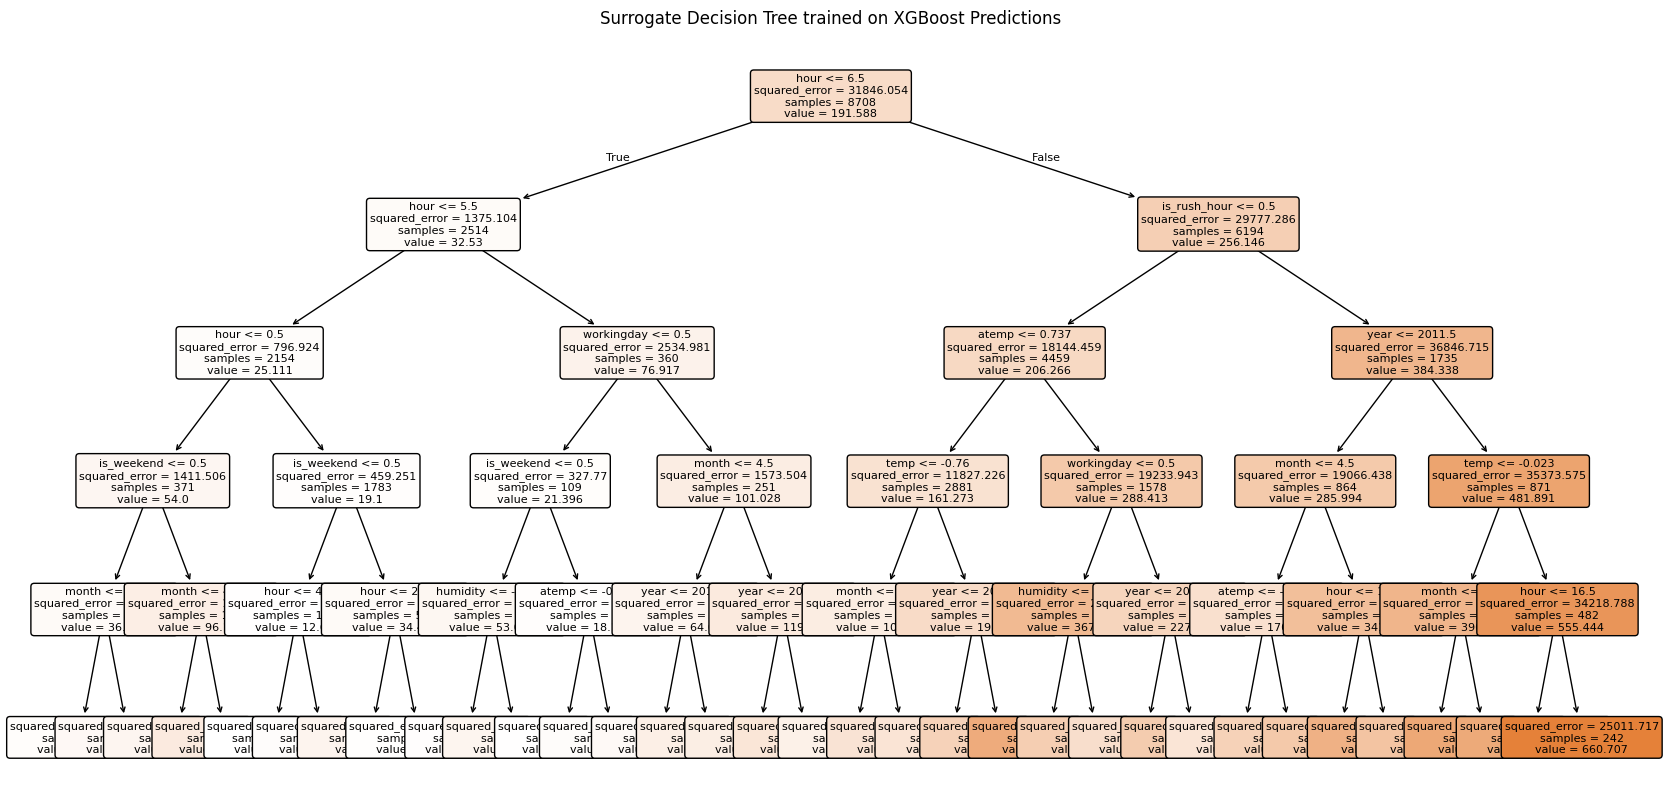

Surrogate Decision Tree generated for XGBoost.


In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train a Decision Tree Regressor on the XGBoost predictions
surrogate_tree = DecisionTreeRegressor(max_depth=5, random_state=42) # Limiting depth for interpretability
surrogate_tree.fit(x_train, model_xgb.predict(x_train))

plt.figure(figsize=(20, 10))
plot_tree(surrogate_tree, feature_names=x_train.columns, filled=True, rounded=True, fontsize=8)
plt.title('Surrogate Decision Tree trained on XGBoost Predictions')
plt.show()

print("Surrogate Decision Tree generated for XGBoost.")

#### Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE) Plots

Partial Dependence Plots (PDPs) show the marginal effect of one or two features on the predicted outcome of a machine learning model. ICE plots display the dependence of the predicted outcome on a feature for each sample separately, providing a more granular view than PDPs.

Generating PDP and ICE plots for top 2 features: ['is_rush_hour', 'year']


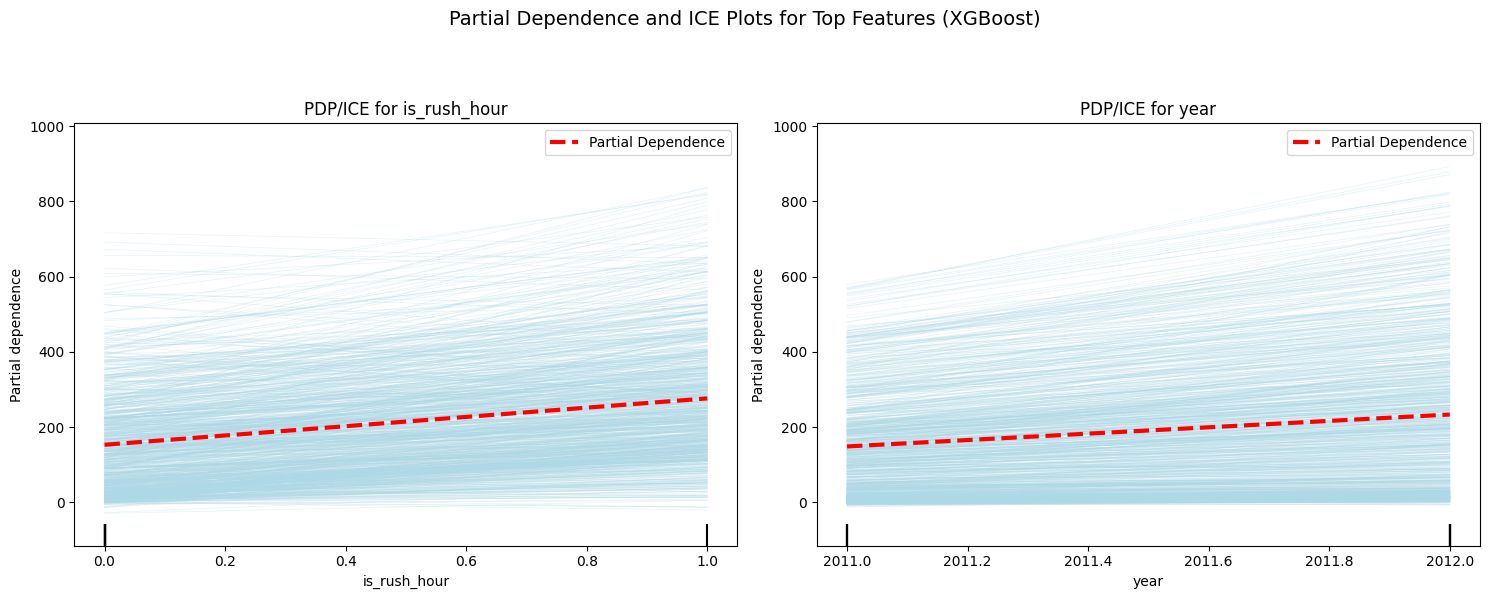

Customized PDP and ICE plots generated for top 2 features with XGBoost.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns # Used for potentially better default styles, though not directly modifying seaborn here

# Get the top 2 features from the feature importances (re-calculating based on XGBoost)
# Ensure features_df is updated by running the Feature Importance cell first if this cell is run independently
# For sequential execution, features_df will already be updated for XGBoost
top_2_features = features_df['Feature'].head(2).tolist()

print(f"Generating PDP and ICE plots for top 2 features: {top_2_features}")

fig, ax = plt.subplots(ncols=len(top_2_features), figsize=(15, 6))

# Generate the plots using the XGBoost model
display_object = PartialDependenceDisplay.from_estimator(
    model_xgb, x_train, top_2_features,
    kind='both', # Shows both PDP and ICE
    feature_names=x_train.columns.tolist(),
    ax=ax
)

# Customizing the plots
# When ncols > 1, ax (and thus display_object.axes_) is a 1D array of Axes objects.
for i, current_ax in enumerate(display_object.axes_):

    # Set title for each subplot
    current_ax.set_title(f"PDP/ICE for {top_2_features[i]}", fontsize=12)

    # Customize lines
    lines = current_ax.get_lines()
    if len(lines) > 1: # If there are ICE lines and a PDP line
        # ICE lines (all but the last one)
        for line in lines[:-1]:
            line.set_color('lightblue')
            line.set_alpha(0.3)
            line.set_linewidth(0.5)
        # PDP line (the last one)
        pdp_line = lines[-1]
        pdp_line.set_color('red')
        pdp_line.set_linewidth(3)
        pdp_line.set_linestyle('--')
        pdp_line.set_label('Partial Dependence')
    elif len(lines) == 1: # Only PDP line (for robustness, if kind='both' doesn't produce ICE)
        pdp_line = lines[0]
        pdp_line.set_color('red')
        pdp_line.set_linewidth(3)
        pdp_line.set_linestyle('--')
        pdp_line.set_label('Partial Dependence')

    current_ax.legend() # Add legend for PDP line


fig.suptitle('Partial Dependence and ICE Plots for Top Features (XGBoost)', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Customized PDP and ICE plots generated for top 2 features with XGBoost.")

#### SHAP Beeswarm Plot (Regression)

SHAP (SHapley Additive exPlanations) values help us understand how each feature contributes to the prediction of a machine learning model. A Beeswarm plot summarizes the SHAP values for each feature across many samples, showing the distribution of impacts and revealing which features are most important and how they influence the model's output (positive or negative impact).

In [ ]:
# Install shap library if not already installed
!pip install shap

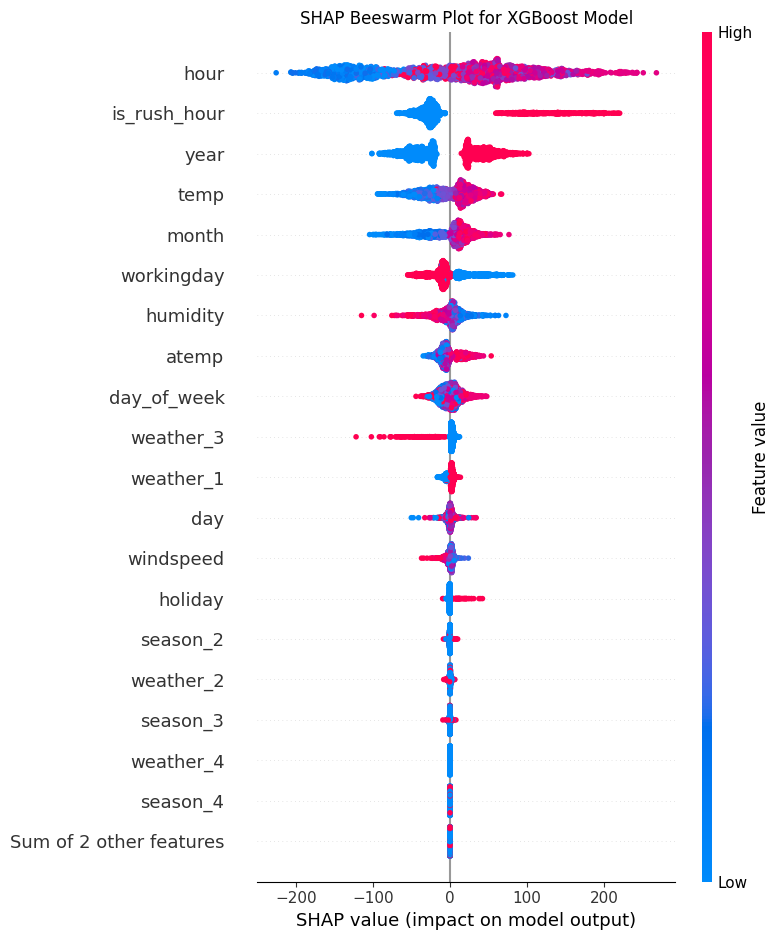

SHAP Beeswarm plot generated for the XGBoost model.


In [ ]:
import shap
import matplotlib.pyplot as plt

# Create a SHAP TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(model_xgb)

# Calculate SHAP values for the test set
shap_values = explainer(x_test)

# Plot the SHAP Beeswarm plot
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm Plot for XGBoost Model')
plt.tight_layout()
plt.show()

print("SHAP Beeswarm plot generated for the XGBoost model.")

#### SHAP Bar Plot (Regression)

A SHAP bar plot provides a global overview of feature importance by showing the average absolute SHAP value for each feature. This helps to quickly identify the features that contribute most to the model's predictions, without showing the direction or distribution of impact (which the Beeswarm plot provides).

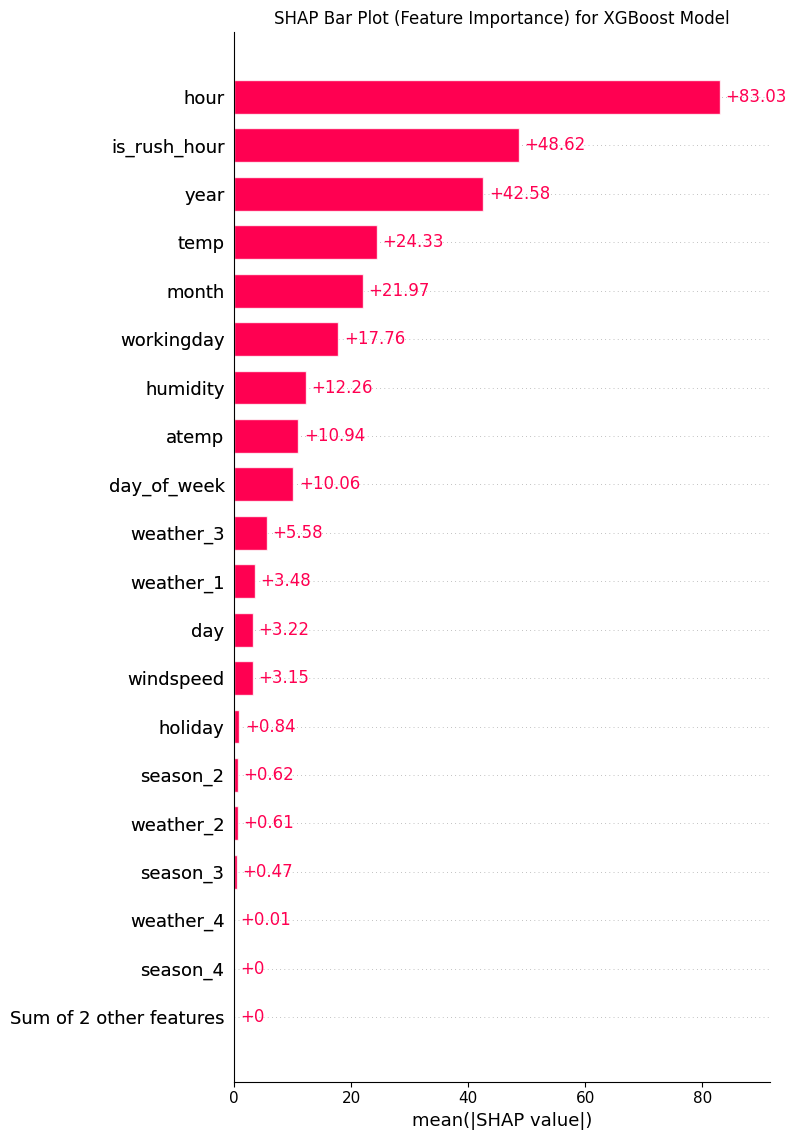

SHAP Bar plot generated for the XGBoost model.


In [ ]:
import shap
import matplotlib.pyplot as plt

# Assuming explainer and shap_values are already computed from the previous cell for XGBoost

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('SHAP Bar Plot (Feature Importance) for XGBoost Model')
plt.tight_layout()
plt.show()

print("SHAP Bar plot generated for the XGBoost model.")

#### Explainability Method Comparison Summary

To conclude our exploration of model explainability, here's a comparative summary of the methods we've applied. This table provides a subjective rating (1-5, where 5 is best) for each method based on key criteria, helping to illustrate their typical use cases and insights provided.

Explainability method comparison summary generated.


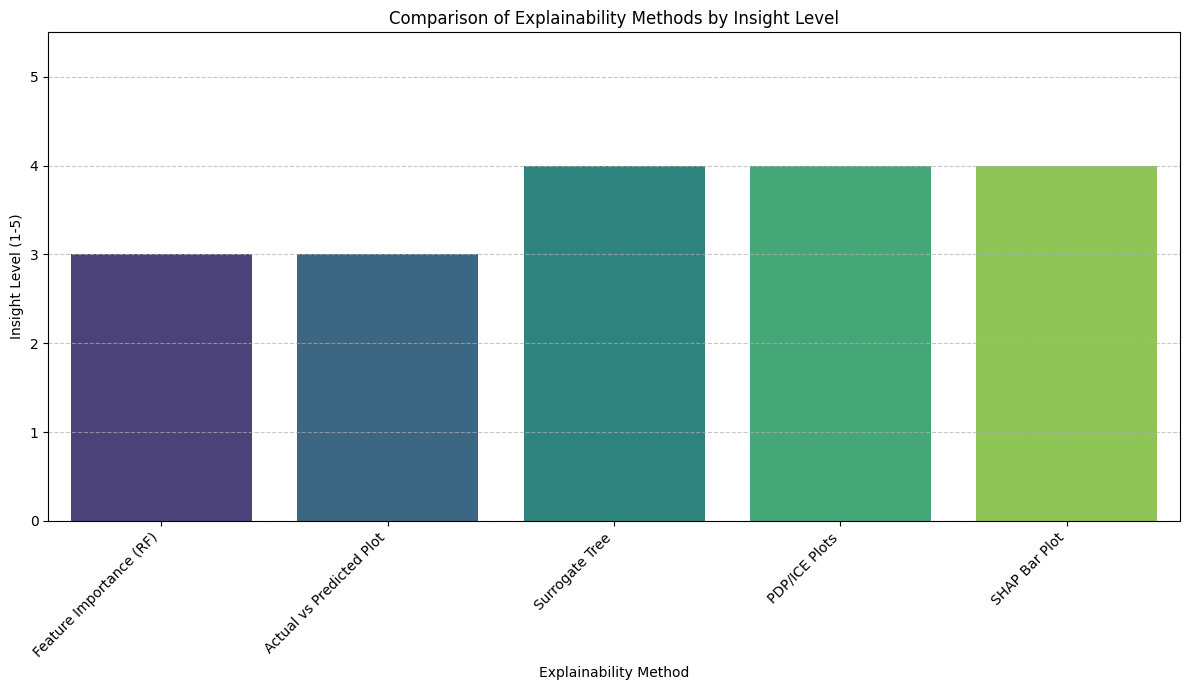

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

comparison_data = {
    'Method': [
        'Feature Importance (RF)',
        'Actual vs Predicted Plot',
        'Surrogate Tree',
        'PDP/ICE Plots',
        'SHAP Beeswarm Plot',
        'SHAP Bar Plot'
    ],
    'Interpretability (1-5)': [
        4, # Clear what features matter
        5, # Direct visual comparison
        3, # Simpler model, can get complex with depth
        4, # Shows marginal effect, clear trends
        4, # Detailed, shows distribution and direction
        4  # Clear ranking of overall importance
    ],
    'Local vs Global': [
        'Global',
        'Global',
        'Mixed (Local/Global)',
        'Mixed (PDP Global, ICE Local)',
        'Mixed (Summarizes Local to Global)',
        'Global'
    ],
    'Model Specificity': [
        'Model-specific',
        'Model-agnostic',
        'Model-agnostic',
        'Model-agnostic',
        'Model-specific (Tree-based, but adaptable)',
        'Model-specific (Tree-based, but adaptable)'
    ],
    'Complexity (1-5)': [
        2, # Easy to understand
        1, # Very simple to create and understand
        3, # Requires training another model, interpretation of tree structure
        3, # Can be computationally intensive, understanding nuances
        4, # SHAP values themselves can be complex to compute and fully grasp
        3  # Easier to interpret than Beeswarm for just importance
    ],
    'Insight Level (1-5)': [
        3, # Identifies important features, but not how they influence
        3, # Shows overall performance, identifies outliers, but not feature impact
        4, # Mimics complex model's decisions
        4, # Reveals functional relationship between features and predictions
        5, # Comprehensive, shows impact, direction, and interaction
        4  # Quick summary of global importance
    ]
}

comparison_summary_df = pd.DataFrame(comparison_data)

print("Explainability method comparison summary generated.")

# Filter to include only one SHAP method (e.g., SHAP Bar Plot for a 'lighter' representation)
# And plot Insight Level
plot_df = comparison_summary_df[comparison_summary_df['Method'] != 'SHAP Beeswarm Plot'].copy()

plt.figure(figsize=(12, 7))
sns.barplot(x='Method', y='Insight Level (1-5)', data=plot_df, palette='viridis', hue='Method', legend=False)
plt.title('Comparison of Explainability Methods by Insight Level')
plt.xlabel('Explainability Method')
plt.ylabel('Insight Level (1-5)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5.5) # Set y-axis limit to clearly show the 1-5 scale
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Deploying a Simple Graphical User Interface (GUI)

To create a simple graphical user interface (GUI) for the bike sharing demand prediction model, we will use a Flask web application. This application will allow users to input parameters and receive a demand prediction. We will also use `pyngrok` to expose the local Flask server to the internet, enabling interaction directly from your browser.

### Installation of Necessary Libraries

In [ ]:
!pip install Flask pyngrok joblib

# Import pyngrok to establish a tunnel to the Flask app
from pyngrok import ngrok

print("Required libraries installed.")

Required libraries installed.


### Saving the Model, Scaler, and Feature Names

The Flask application will run as a separate process and will not have direct access to the Colab kernel's memory. Therefore, we need to save the trained XGBoost model, the fitted `StandardScaler`, and the list of feature columns (to ensure correct input order) to disk. We'll use `joblib` for this.

In [ ]:
import joblib
import os

# Create a directory to store model components
model_dir = 'model_components'
os.makedirs(model_dir, exist_ok=True)

# Save the trained XGBoost model
joblib.dump(model_xgb, os.path.join(model_dir, 'xgboost_model.pkl'))

# Save the fitted StandardScaler
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))

# Save the list of feature names (x_train.columns) to ensure correct order during prediction
joblib.dump(x_train.columns.tolist(), os.path.join(model_dir, 'feature_names.pkl'))

print(f"Model, scaler, and feature names saved to '{model_dir}' directory.")

Model, scaler, and feature names saved to 'model_components' directory.


### Creating the Flask Application Files

We'll create three files:
1.  `app.py`: The main Flask application logic, including feature engineering, scaling, prediction, and input validation.
2.  `templates/index.html`: The HTML template for the input form.
3.  `templates/predict.html`: The HTML template to display the prediction result.

First, let's create the `templates` directory.

In [ ]:
import os
os.makedirs('templates', exist_ok=True)
print("'templates' directory created.")

'templates' directory created.


In [ ]:
%%writefile app.py
from flask import Flask, request, render_template, redirect, url_for
import joblib
import pandas as pd
import numpy as np
from datetime import datetime
import os

app = Flask(__name__)

# Load the model components
model_dir = 'model_components'
model = joblib.load(os.path.join(model_dir, 'xgboost_model.pkl'))
scheduler = joblib.load(os.path.join(model_dir, 'scaler.pkl'))
feature_names = joblib.load(os.path.join(model_dir, 'feature_names.pkl'))

# Define the numerical columns that need scaling
NUMERIC_COLS_TO_SCALE = ['temp', 'atemp', 'humidity', 'windspeed']

@app.route('/', methods=['GET'])
def home():
    # Render the input form
    return render_template('index.html', error=None)

@app.route('/predict', methods=['POST'])
def predict():
    if request.method == 'POST':
        try:
            # 1. Get input data from form and perform basic validation
            input_data = {
                'datetime_str': request.form['datetime_input'],
                'season': int(request.form['season']),
                'holiday': int(request.form['holiday']),
                'workingday': int(request.form['workingday']),
                'weather': int(request.form['weather']),
                'temp': float(request.form['temp']),
                'atemp': float(request.form['atemp']),
                'humidity': float(request.form['humidity']),
                'windspeed': float(request.form['windspeed'])
            }

            # --- Input Validation ---
            # Check ranges for numerical features
            if not (0 <= input_data['humidity'] <= 100): # Assuming humidity is percentage
                raise ValueError("Humidity must be between 0 and 100.")
            if not (0 <= input_data['windspeed'] <= 67): # Max windspeed observed in training data was ~67
                raise ValueError("Windspeed must be between 0 and 67.")
            # Add more validation as needed (e.g., for temp, atemp ranges based on domain knowledge)

            # Check categorical feature values
            if input_data['season'] not in [1, 2, 3, 4]:
                raise ValueError("Season must be 1, 2, 3, or 4.")
            if input_data['weather'] not in [1, 2, 3, 4]:
                raise ValueError("Weather must be 1, 2, 3, or 4.")
            if input_data['holiday'] not in [0, 1]:
                raise ValueError("Holiday must be 0 or 1.")
            if input_data['workingday'] not in [0, 1]:
                raise ValueError("Workingday must be 0 or 1.")

            # 2. Feature Engineering (replicate notebook's preprocessing)
            dt_obj = datetime.strptime(input_data['datetime_str'], '%Y-%m-%dT%H:%M')

            # Create a dictionary to build the DataFrame with correct dtypes
            data_dict = {}

            # Populate numerical and directly assigned categorical features, casting to bool where necessary
            data_dict['holiday'] = bool(input_data['holiday'])
            data_dict['workingday'] = bool(input_data['workingday'])
            data_dict['temp'] = input_data['temp']
            data_dict['atemp'] = input_data['atemp']
            data_dict['humidity'] = input_data['humidity']
            data_dict['windspeed'] = input_data['windspeed']
            data_dict['hour'] = dt_obj.hour
            data_dict['day'] = dt_obj.day
            data_dict['month'] = dt_obj.month
            data_dict['year'] = dt_obj.year
            data_dict['day_of_week'] = dt_obj.weekday()

            data_dict['is_weekend'] = bool(data_dict['day_of_week'] >= 5)
            data_dict['is_rush_hour'] = False # Initialize as bool
            if (data_dict['workingday'] == True) and (data_dict['hour'] in [7, 8, 9, 16, 17, 18, 19]):
                data_dict['is_rush_hour'] = True

            # Initialize all one-hot encoded season/weather columns to False (boolean)
            for i in range(1, 5):
                season_col = f'season_{i}'
                if season_col in feature_names:
                    data_dict[season_col] = False
                weather_col = f'weather_{i}'
                if weather_col in feature_names:
                    data_dict[weather_col] = False

            # Set the active season/weather columns to True
            active_season_col = f'season_{input_data["season"]}'
            if active_season_col in feature_names:
                data_dict[active_season_col] = True

            active_weather_col = f'weather_{input_data["weather"]}'
            if active_weather_col in feature_names:
                data_dict[active_weather_col] = True

            # Create DataFrame, ensuring column order matches training and preserving types
            input_df = pd.DataFrame([data_dict], columns=feature_names)

            # Apply scaling to numerical features
            input_df[NUMERIC_COLS_TO_SCALE] = scheduler.transform(input_df[NUMERIC_COLS_TO_SCALE])

            # 3. Make prediction
            prediction = model.predict(input_df)[0]
            prediction = max(0, round(prediction)) # Ensure non-negative and integer prediction

            return render_template('predict.html', prediction=prediction)

        except ValueError as e:
            # Handle validation errors
            return render_template('index.html', error=str(e))
        except Exception as e:
            # Handle other potential errors
            return render_template('index.html', error=f"An unexpected error occurred: {str(e)}")


if __name__ == '__main__':
    app.run(port=5000, use_reloader=False, debug=False)


Writing app.py


In [ ]:
%%writefile templates/index.html
<!DOCTYPE html>
<html>
<head>
    <title>Bike Demand Predictor</title>
    <link href="https://stackpath.bootstrapcdn.com/bootstrap/4.5.2/css/bootstrap.min.css" rel="stylesheet">
    <style>
        body { padding: 20px; background-color: #f8f9fa; }
        .container { max-width: 700px; background-color: #ffffff; padding: 30px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,.1); }
        .form-group label { font-weight: bold; }
        .btn-primary { background-color: #007bff; border-color: #007bff; }
        .btn-primary:hover { background-color: #0056b3; border-color: #0056b3; }
        .alert { margin-top: 20px; }
    </style>
</head>
<body>
    <div class="container">
        <h2 class="mb-4 text-center">Bike Sharing Demand Predictor</h2>
        {% if error %}
            <div class="alert alert-danger" role="alert">
                Error: {{ error }}
            </div>
        {% endif %}
        <form action="/predict" method="post">
            <div class="form-group">
                <label for="datetime_input">Datetime:</label>
                <input type="datetime-local" class="form-control" id="datetime_input" name="datetime_input" value="2012-01-01T12:00" required>
            </div>
            <div class="form-row">
                <div class="form-group col-md-6">
                    <label for="season">Season:</label>
                    <select class="form-control" id="season" name="season" required>
                        <option value="1">1: Spring</option>
                        <option value="2">2: Summer</option>
                        <option value="3">3: Fall</option>
                        <option value="4">4: Winter</option>
                    </select>
                </div>
                <div class="form-group col-md-6">
                    <label for="weather">Weather:</label>
                    <select class="form-control" id="weather" name="weather" required>
                        <option value="1">1: Clear</option>
                        <option value="2">2: Mist</option>
                        <option value="3">3: Light Rain/Snow</option>
                        <option value="4">4: Heavy Rain/Storm</option>
                    </select>
                </div>
            </div>
            <div class="form-row">
                <div class="form-group col-md-6">
                    <label for="holiday">Holiday:</label>
                    <select class="form-control" id="holiday" name="holiday" required>
                        <option value="0">0: No</option>
                        <option value="1">1: Yes</option>
                    </select>
                </div>
                <div class="form-group col-md-6">
                    <label for="workingday">Working Day:</label>
                    <select class="form-control" id="workingday" name="workingday" required>
                        <option value="0">0: Weekend/Holiday</option>
                        <option value="1">1: Working Day</option>
                    </select>
                </div>
            </div>
            <div class="form-row">
                <div class="form-group col-md-4">
                    <label for="temp">Temperature (°C):</label>
                    <input type="number" step="0.1" class="form-control" id="temp" name="temp" value="14.0" required>
                </div>
                <div class="form-group col-md-4">
                    <label for="atemp">Feels Like Temp (°C):</label>
                    <input type="number" step="0.1" class="form-control" id="atemp" name="atemp" value="16.0" required>
                </div>
                <div class="form-group col-md-4">
                    <label for="humidity">Humidity (%):</label>
                    <input type="number" step="1" class="form-control" id="humidity" name="humidity" value="60" required>
                </div>
            </div>
            <div class="form-group">
                <label for="windspeed">Windspeed (m/s):</label>
                <input type="number" step="0.1" class="form-control" id="windspeed" name="windspeed" value="10.0" required>
            </div>
            <button type="submit" class="btn btn-primary btn-block">Predict Demand</button>
        </form>
    </div>
</body>
</html>


Writing templates/index.html


In [ ]:
%%writefile templates/predict.html
<!DOCTYPE html>
<html>
<head>
    <title>Prediction Result</title>
    <link href="https://stackpath.bootstrapcdn.com/bootstrap/4.5.2/css/bootstrap.min.css" rel="stylesheet">
    <style>
        body { padding: 20px; background-color: #f8f9fa; }
        .container { max-width: 600px; background-color: #ffffff; padding: 30px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,.1); text-align: center; }
        .result-box { margin-top: 30px; padding: 20px; background-color: #e9ecef; border-radius: 5px; }
        .result-box h3 { color: #007bff; }
        .btn-secondary { background-color: #6c757d; border-color: #6c757d; }
        .btn-secondary:hover { background-color: #5a6268; border-color: #5a6268; }
    </style>
</head>
<body>
    <div class="container">
        <h2 class="mb-4">Prediction Result</h2>
        <div class="result-box">
            <h3>Predicted Bike Rentals:</h3>
            <h1>{{ prediction }}</h1>
        </div>
        <a href="/" class="btn btn-secondary mt-4">Make Another Prediction</a>
    </div>
</body>
</html>


Writing templates/predict.html


### Running the Flask Application with ngrok

This cell will start the Flask server and create a public URL using ngrok. Click on the ngrok URL to access your GUI. The server will run until this cell's execution is stopped.

In [ ]:
from threading import Thread
import time
import os

# Terminate ngrok tunnels if any are already running
ngrok.kill()

# --- ADDED: ngrok authentication token ---
# You need to sign up for a free ngrok account, get your authtoken, and replace 'YOUR_NGROK_AUTH_TOKEN' below.
# Visit: https://dashboard.ngrok.com/get-started/your-authtoken
# You can also set this as a Colab secret for better security.
NGROK_AUTH_TOKEN = "3DUz38nhjiMlaNRjBNkC61FSD9j_7ygdK9tmiXSauYg1WAQ1Z" # REPLACE WITH YOUR NGROK AUTH TOKEN
if NGROK_AUTH_TOKEN == "YOUR_NGROK_AUTH_TOKEN":
    print("Please replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authtoken.")
    raise ValueError("Ngrok authtoken not set.")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
# --- END ADDED SECTION ---

# Start ngrok tunnel in a background thread
def start_ngrok():
    global public_url
    try:
        http_tunnel = ngrok.connect(5000)
        public_url = http_tunnel.public_url
        print(f"* ngrok tunnel available at: {public_url}")
    except Exception as e:
        print(f"Error starting ngrok: {e}")
        public_url = None

ngrok_thread = Thread(target=start_ngrok)
ngrok_thread.daemon = True
ngrok_thread.start()

# Wait a moment for ngrok to establish the tunnel
time.sleep(5)

# Start Flask app
# Ensure the app is run from the 'app.py' file
!python app.py


* ngrok tunnel available at: https://barrack-slam-remark.ngrok-free.dev
 * Serving Flask app 'app'
 * Debug mode: off
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [04/Jun/2026 07:03:16] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [04/Jun/2026 07:03:18] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [04/Jun/2026 07:04:33] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/Jun/2026 07:05:15] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [04/Jun/2026 07:22:44] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/Jun/2026 07:22:52] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [04/Jun/2026 08:19:08] "POST /predict HTTP/1.1" 200 -


### How to Use the GUI

1.  **Run all the cells above** to install libraries, save the model, and create the Flask app files.
2.  **Execute the last code cell** (the one that starts `!python app.py`).
3.  Look for the output line that says `* ngrok tunnel available at: [your_public_url]`. **Click on the provided URL**.
4.  This will open a new browser tab with your Bike Sharing Demand Predictor GUI.
5.  **Enter the required input values** (datetime, season, weather, holiday, working day, temperature, humidity, windspeed).
6.  **Click 'Predict Demand'** to see the model's prediction.

**Note**: If you restart your Colab runtime, you will need to re-run all the relevant cells (from loading data to model training) before running the GUI cells again, as the model and scaler objects will be lost from memory.